Лабораторна робота
Тема: Аналіз та прогнозування випадків туберкульозу в Індії за допомогою регресійних моделей
1. Попередня обробка даних:
1.1 Завантажити та оглянути набір даних.

In [926]:
import pandas as pd
import matplotlib.pyplot as plt

In [927]:
#Loading file as dataframe
file_path = 'filledfinaldata.xlsx'
df = pd.read_excel(file_path)

pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
                        City  Year  Active Case Finding TB cases diagnosed among tested  Active Case Finding TB Presumptive TB cases tested out of those screened  MDR/RR TB DIAGNOSED MDR/RR patient diagnosed  Paediatric TB patients notified  TB case notification total  TB Cases Notified Female  TB Cases Notified Male  TB patients with known Tobacco usage status  TB-HIV co-infected patients Diagnosed  TB-HIV co-infected patients Put on ART  Treatment outcome of TB patients notified in (% Lost to follow up)  Treatment outcome of TB patients notified in (Death Rate)  Treatment outcome of TB patients notified in (Success Rate)  Treatment outcome of TB patients notified in (Treatment Failure Rate)  Treatment outcome of TB-HIV patients notified in (Death Rate)  Treatment outcome of TB-HIV patients notified in (Success Rate)  PMDT- Infrastructure No. of Nodal DR-TB centres  TB- DM patients initiated on Anti-diabetic treatment  Treatment outcome of Paediatric TB pa

In [928]:
# Display information about the dataset
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 26 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   City                                                                      148 non-null    object 
 1   Year                                                                      148 non-null    int64  
 2   Active Case Finding TB cases diagnosed among tested                       148 non-null    int64  
 3   Active Case Finding TB Presumptive TB cases tested out of those screened  148 non-null    int64  
 4   MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                              148 non-null    int64  
 5   Paediatric TB patients notified                                           148 non-null    int64  
 6   TB case notification total                  

In [929]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  

# Display descriptive statistics of numerical columns
print("\nDescriptive statistics of numerical columns:")
print(df.describe())


Descriptive statistics of numerical columns:
             Year  Active Case Finding TB cases diagnosed among tested  Active Case Finding TB Presumptive TB cases tested out of those screened  MDR/RR TB DIAGNOSED MDR/RR patient diagnosed  Paediatric TB patients notified  TB case notification total  TB Cases Notified Female  TB Cases Notified Male  TB patients with known Tobacco usage status  TB-HIV co-infected patients Diagnosed  TB-HIV co-infected patients Put on ART  Treatment outcome of TB patients notified in (% Lost to follow up)  Treatment outcome of TB patients notified in (Death Rate)  Treatment outcome of TB patients notified in (Success Rate)  Treatment outcome of TB patients notified in (Treatment Failure Rate)  Treatment outcome of TB-HIV patients notified in (Death Rate)  Treatment outcome of TB-HIV patients notified in (Success Rate)  PMDT- Infrastructure No. of Nodal DR-TB centres  TB- DM patients initiated on Anti-diabetic treatment  Treatment outcome of Paediatric TB pa

1.2 Перевірити наявність пропущених значень.

In [930]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
City                                                                        0
Year                                                                        0
Active Case Finding TB cases diagnosed among tested                         0
Active Case Finding TB Presumptive TB cases tested out of those screened    0
MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                                0
Paediatric TB patients notified                                             0
TB case notification total                                                  0
TB Cases Notified Female                                                    0
TB Cases Notified Male                                                      0
TB patients with known Tobacco usage status                                 0
TB-HIV co-infected patients Diagnosed                                       0
TB-HIV co-infected patients Put on ART                                      0
Treatment outcome of TB patients noti

In [931]:
# Check for empty strings in object-type columns
empty_strings = (df.select_dtypes(include=['object']) == '').sum()

print("Empty string values per text column:")
print(empty_strings[empty_strings > 0])

Empty string values per text column:
Series([], dtype: int64)


1.3 Видалити або заповнити пропущені значення (за потреби).

1.4 Виключити нерелевантні змінні (наприклад, текстові колонки).

In [934]:
print("Column data types:")

print(df.dtypes)
len(df)

Column data types:
City                                                                         object
Year                                                                          int64
Active Case Finding TB cases diagnosed among tested                           int64
Active Case Finding TB Presumptive TB cases tested out of those screened      int64
MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                                  int64
Paediatric TB patients notified                                               int64
TB case notification total                                                    int64
TB Cases Notified Female                                                      int64
TB Cases Notified Male                                                        int64
TB patients with known Tobacco usage status                                   int64
TB-HIV co-infected patients Diagnosed                                         int64
TB-HIV co-infected patients Put on ART                   

148

In [933]:
# Drop non-numeric (text) columns
df_numeric = df.select_dtypes(include=['number'])

print(df_numeric.dtypes)
len(df)

Year                                                                          int64
Active Case Finding TB cases diagnosed among tested                           int64
Active Case Finding TB Presumptive TB cases tested out of those screened      int64
MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                                  int64
Paediatric TB patients notified                                               int64
TB case notification total                                                    int64
TB Cases Notified Female                                                      int64
TB Cases Notified Male                                                        int64
TB patients with known Tobacco usage status                                   int64
TB-HIV co-infected patients Diagnosed                                         int64
TB-HIV co-infected patients Put on ART                                        int64
Treatment outcome of TB patients notified in (% Lost to follow up)          

148

1.5 Виконати стандартизацію числових даних.

In [935]:
from sklearn.preprocessing import StandardScaler

In [937]:
# Initialize the standard scaler
scaler = StandardScaler()

# Apply standardization to the numeric data
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  

# Display the first 5 rows of the standardized data
print(df_scaled.head(15))

        Year  Active Case Finding TB cases diagnosed among tested  Active Case Finding TB Presumptive TB cases tested out of those screened  MDR/RR TB DIAGNOSED MDR/RR patient diagnosed  Paediatric TB patients notified  TB case notification total  TB Cases Notified Female  TB Cases Notified Male  TB patients with known Tobacco usage status  TB-HIV co-infected patients Diagnosed  TB-HIV co-infected patients Put on ART  Treatment outcome of TB patients notified in (% Lost to follow up)  Treatment outcome of TB patients notified in (Death Rate)  Treatment outcome of TB patients notified in (Success Rate)  Treatment outcome of TB patients notified in (Treatment Failure Rate)  Treatment outcome of TB-HIV patients notified in (Death Rate)  Treatment outcome of TB-HIV patients notified in (Success Rate)  PMDT- Infrastructure No. of Nodal DR-TB centres  TB- DM patients initiated on Anti-diabetic treatment  Treatment outcome of Paediatric TB patients notified in (Death Rate)  Treatment outcome 

2. Аналіз даних:

2.1 Дослідити кореляції між змінними за допомогою теплової карти.

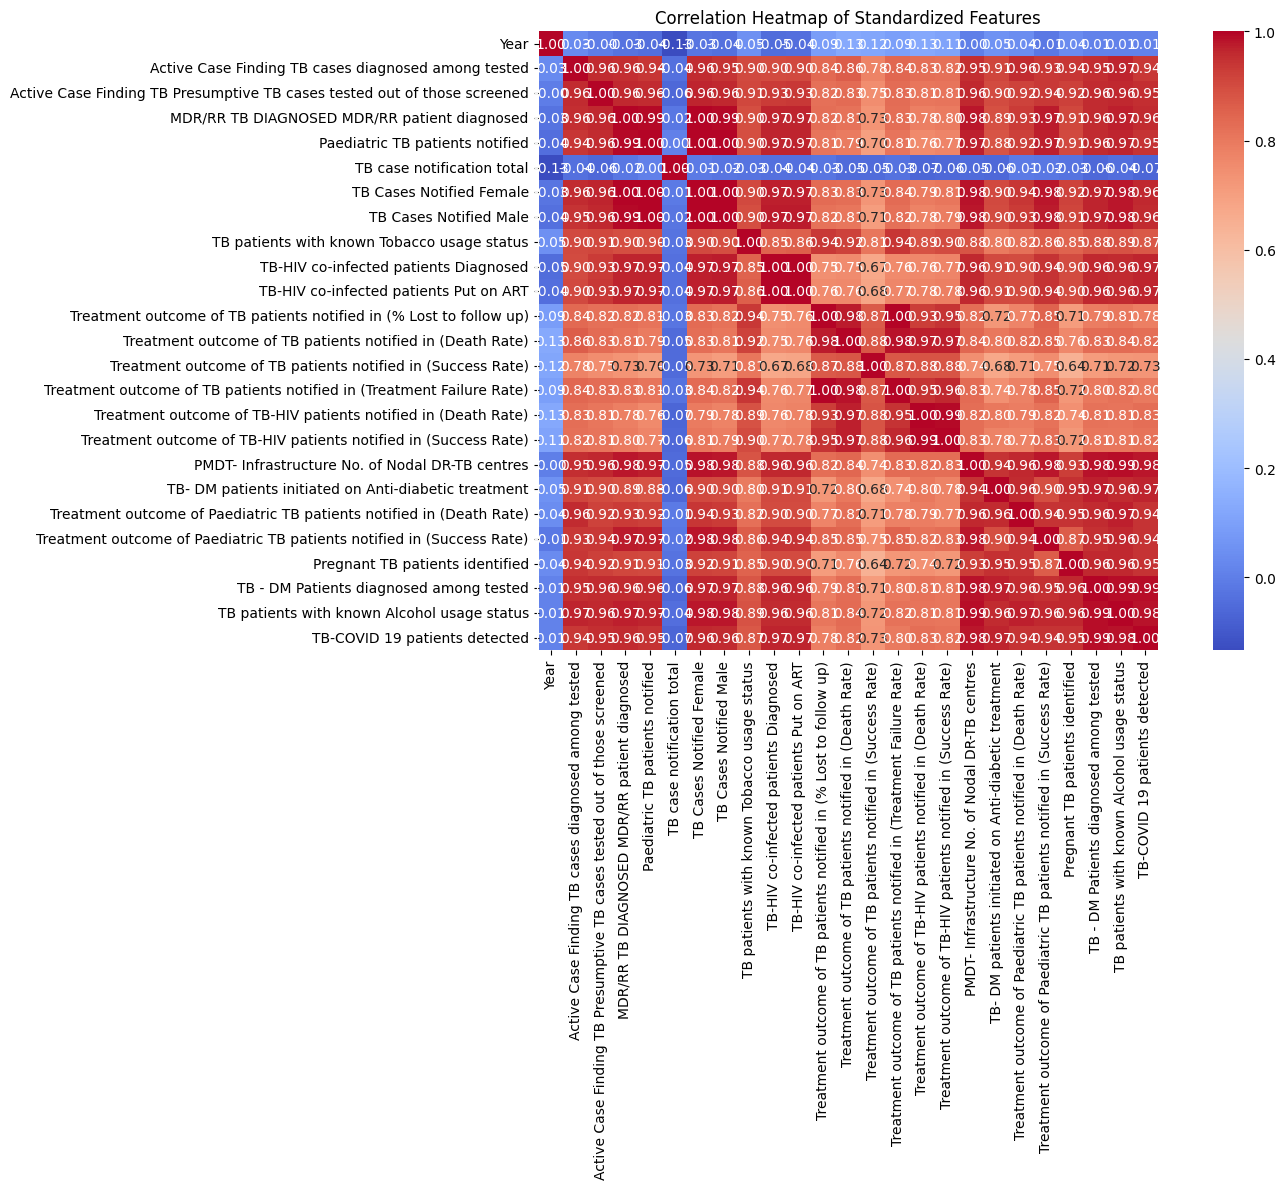

In [938]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# Creating the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)

plt.title("Correlation Heatmap of Standardized Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [939]:
# Flatten the correlation matrix and reset index
corr_pairs = correlation_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

# Drop duplicate pairs (A-B та B-A)
corr_pairs['sorted_pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature 1'], row['Feature 2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='sorted_pair').drop(columns='sorted_pair')

# Sort by absolute correlation value
top_corr = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)    

# Display top 15 most correlated pairs
print("Top 15 most correlated feature pairs:")
print(top_corr.head(15))

Top 15 most correlated feature pairs:
                                                              Feature 1                                                              Feature 2  Correlation
235                               TB-HIV co-infected patients Diagnosed                                 TB-HIV co-infected patients Put on ART     0.999711
157                                            TB Cases Notified Female                                                 TB Cases Notified Male     0.998184
289  Treatment outcome of TB patients notified in (% Lost to follow up)  Treatment outcome of TB patients notified in (Treatment Failure Rate)     0.997133
107                                     Paediatric TB patients notified                                                 TB Cases Notified Male     0.996428
81                         MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                                               TB Cases Notified Female     0.996219
106                       

2.2 Зобразити розподіл цільової змінної (“TB case notification total”).

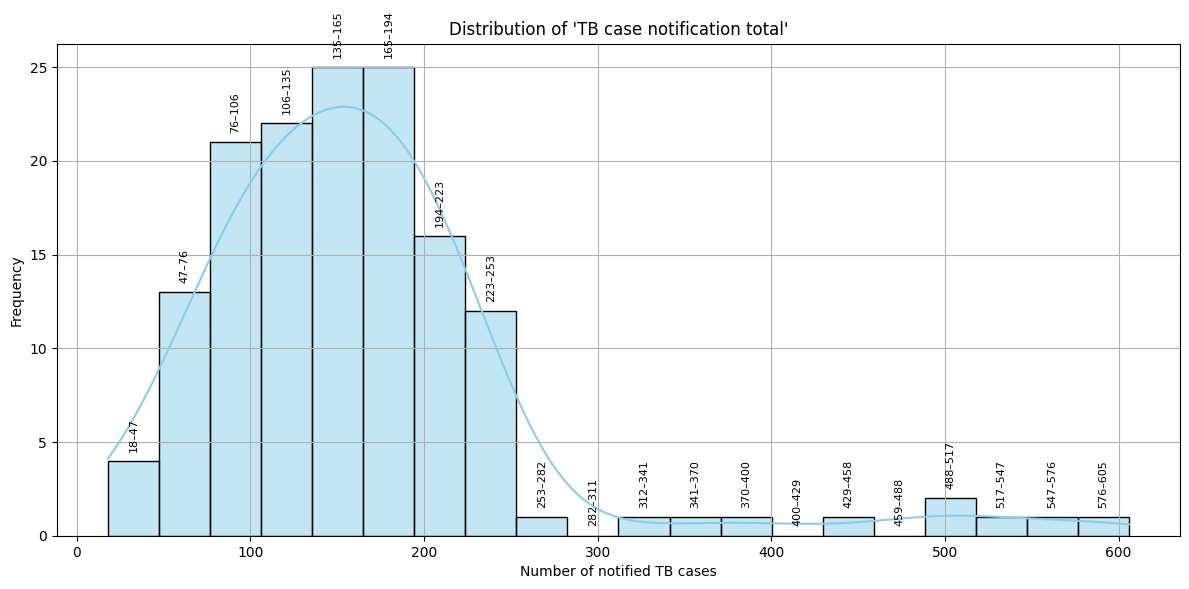

In [940]:
plt.figure(figsize=(12, 6))
hist = sns.histplot(df['TB case notification total'], kde=True, bins=20, color='skyblue')

plt.title("Distribution of 'TB case notification total'")
plt.xlabel("Number of notified TB cases")
plt.ylabel("Frequency")
plt.grid(True)

# Sign every bin 
for patch in hist.patches:
    left = patch.get_x()
    right = left + patch.get_width()
    height = patch.get_height()
    
    # make text
    # Add text above bin
    label = f"{int(left)}–{int(right)}"
    
    plt.text(x=left + patch.get_width()/2, y=height + 0.5, s=label,
             ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

2.3 Побудувати парні графіки (scatter plots) між ключовими факторами та цільовою змінною.

In [941]:
corr_unscaled = df_numeric.corr(numeric_only=True)
top_corr_unscaled = corr_unscaled['TB case notification total'].drop('TB case notification total').abs().sort_values(ascending=False)
print(top_corr_unscaled.head(15))

Year                                                                        0.133838
Treatment outcome of TB-HIV patients notified in (Death Rate)               0.067380
TB-COVID 19 patients detected                                               0.065021
Active Case Finding TB Presumptive TB cases tested out of those screened    0.061964
TB- DM patients initiated on Anti-diabetic treatment                        0.060101
TB - DM Patients diagnosed among tested                                     0.059999
Treatment outcome of TB-HIV patients notified in (Success Rate)             0.059448
PMDT- Infrastructure No. of Nodal DR-TB centres                             0.053079
Treatment outcome of TB patients notified in (Success Rate)                 0.050192
Treatment outcome of TB patients notified in (Death Rate)                   0.049832
TB patients with known Alcohol usage status                                 0.041734
Active Case Finding TB cases diagnosed among tested              

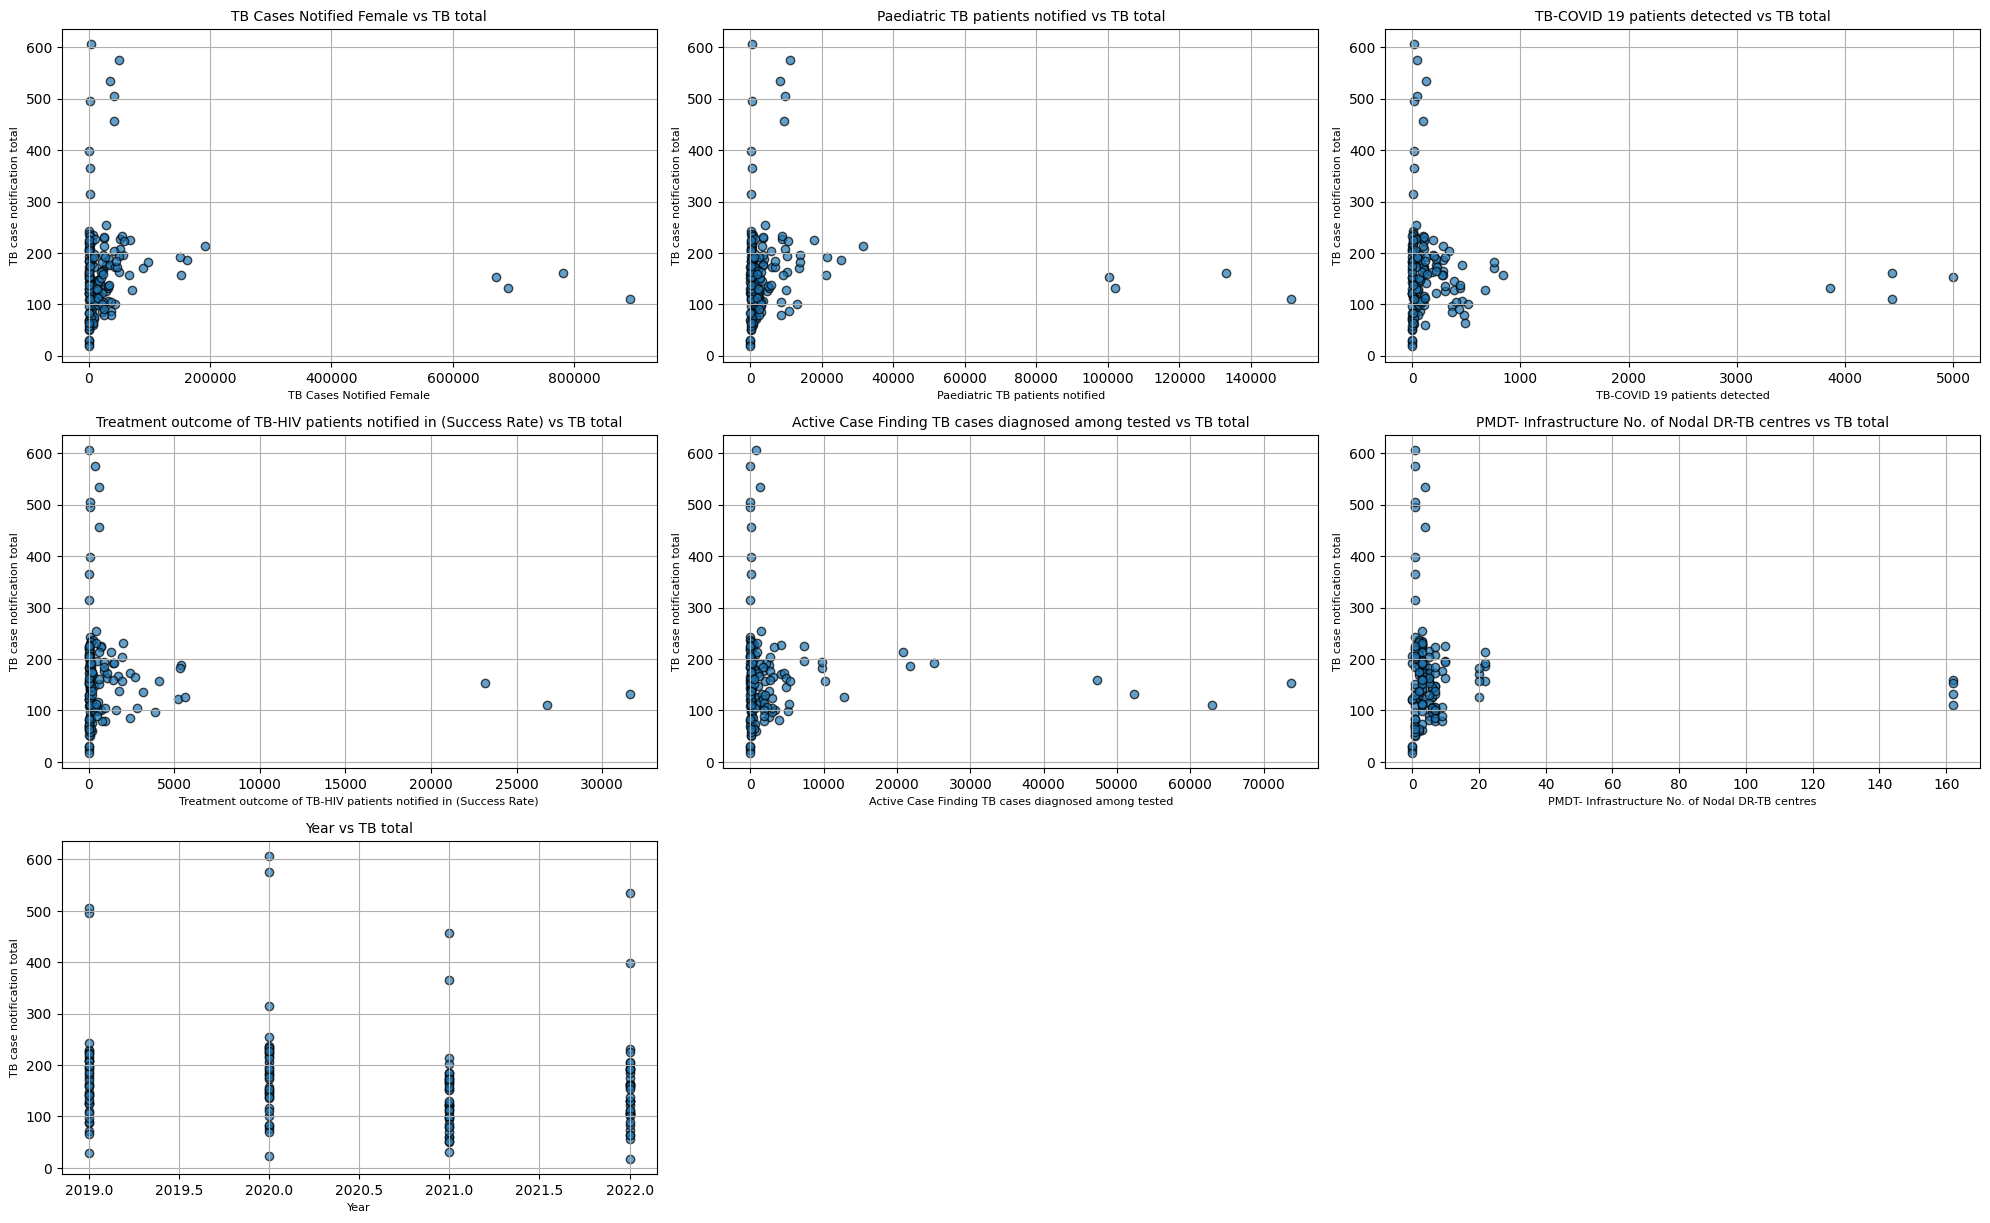

In [942]:
# Top features most correlated with the target variable
features = [
    'TB Cases Notified Female',  # або Total
    'Paediatric TB patients notified',
    'TB-COVID 19 patients detected',
    'Treatment outcome of TB-HIV patients notified in (Success Rate)',
    'Active Case Finding TB cases diagnosed among tested',
    'PMDT- Infrastructure No. of Nodal DR-TB centres',
    'Year'
]

# Create scatter plots
plt.figure(figsize=(20, 16))

for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)  # 4 rows x 3 columns grid
    plt.scatter(df_numeric[feature], df_numeric['TB case notification total'], alpha=0.7, edgecolor='k')
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('TB case notification total', fontsize=8)
    plt.title(f'{feature} vs TB total', fontsize=10)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [943]:
# Копія початкового датафрейму
df_filtered = df_numeric.copy()
features = [
    'TB Cases Notified Female',  # або Total
    'Paediatric TB patients notified',
    'TB-COVID 19 patients detected',
    'Treatment outcome of TB-HIV patients notified in (Success Rate)',
    'Active Case Finding TB cases diagnosed among tested',
    'PMDT- Infrastructure No. of Nodal DR-TB centres',
    'Year'
]

# Поступове застосування масок
df_filtered = df_filtered[df_filtered['TB Cases Notified Female'] <= 200000]
df_filtered = df_filtered[df_filtered['TB case notification total'] <= 300]
df_filtered = df_filtered[df_filtered['Paediatric TB patients notified'] <= 40000]
df_filtered = df_filtered[df_filtered['TB-COVID 19 patients detected'] <= 1000]
df_filtered = df_filtered[df_filtered['Treatment outcome of TB-HIV patients notified in (Success Rate)'] <= 7500]
df_filtered = df_filtered[df_filtered['PMDT- Infrastructure No. of Nodal DR-TB centres'] <= 30]
df_filtered = df_filtered[df_filtered['Active Case Finding TB cases diagnosed among tested'] <= 30000]

# Скидаємо індекси
df_filtered = df_filtered.reset_index(drop=True)

# Результат
print(f"✅ Final rows after all filtering: {len(df_filtered)}")


✅ Final rows after all filtering: 135


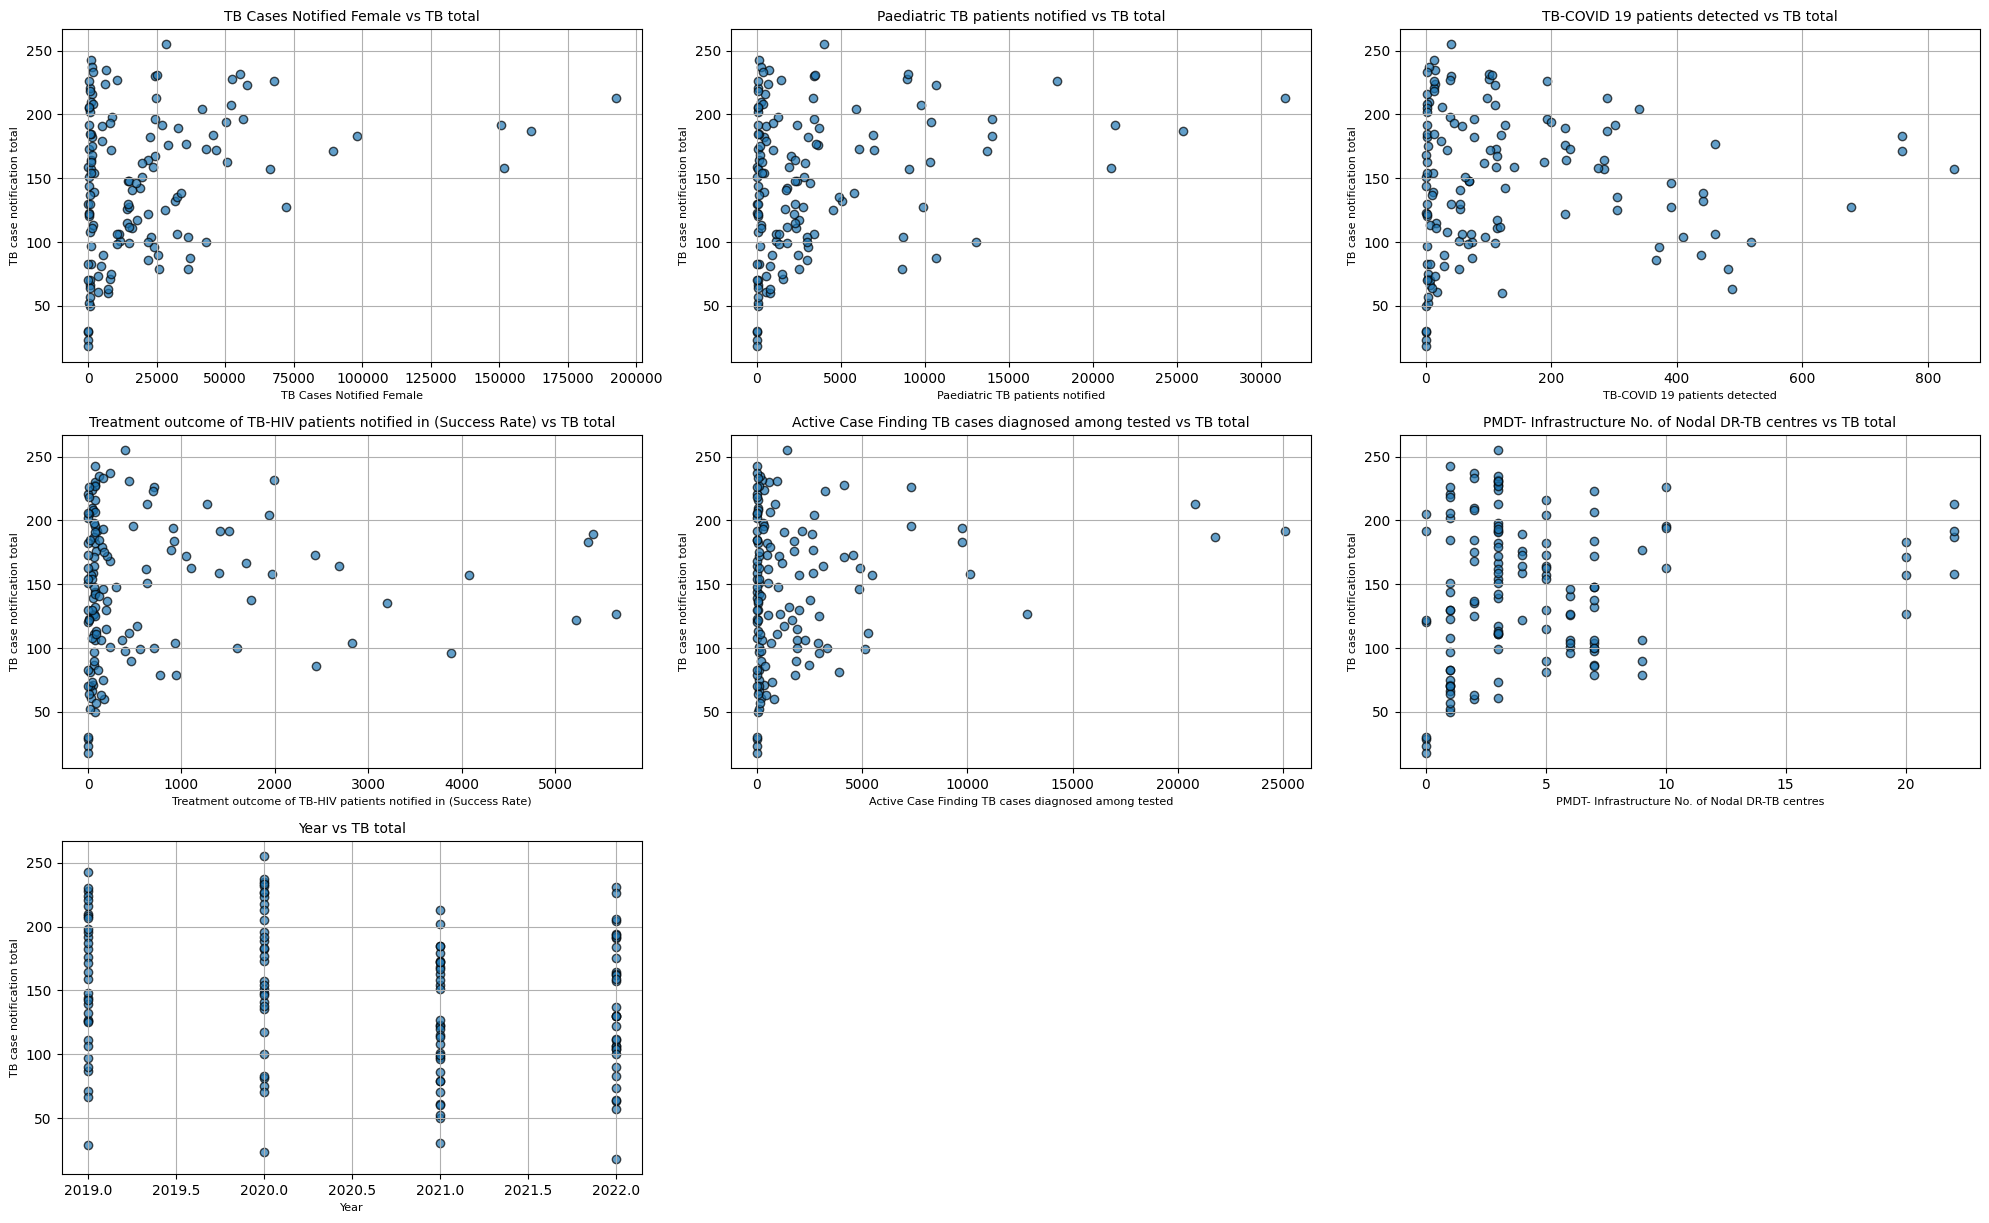

In [944]:
# Top features most correlated with the target variable
features = [
    'TB Cases Notified Female',  # або Total
    'Paediatric TB patients notified',
    'TB-COVID 19 patients detected',
    'Treatment outcome of TB-HIV patients notified in (Success Rate)',
    'Active Case Finding TB cases diagnosed among tested',
    'PMDT- Infrastructure No. of Nodal DR-TB centres',
    'Year'
]

# Create scatter plots
plt.figure(figsize=(20, 16))

for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)  # 4 rows x 3 columns grid
    plt.scatter(df_filtered[feature], df_filtered['TB case notification total'], alpha=0.7, edgecolor='k')
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('TB case notification total', fontsize=8)
    plt.title(f'{feature} vs TB total', fontsize=10)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [945]:
corr_unscaled = df_filtered.corr(numeric_only=True)
top_corr_unscaled = corr_unscaled['TB case notification total'].drop('TB case notification total').abs().sort_values(ascending=False)
print(top_corr_unscaled.head(10))

TB Cases Notified Female                                                  0.251818
TB Cases Notified Male                                                    0.251435
TB patients with known Tobacco usage status                               0.247412
Paediatric TB patients notified                                           0.245668
TB patients with known Alcohol usage status                               0.226155
MDR/RR TB DIAGNOSED MDR/RR patient diagnosed                              0.217358
Year                                                                      0.211922
Treatment outcome of Paediatric TB patients notified in (Success Rate)    0.200780
Pregnant TB patients identified                                           0.198703
Treatment outcome of Paediatric TB patients notified in (Death Rate)      0.183396
Name: TB case notification total, dtype: float64


3. Лінійна регресія:

3.1 Реалізувати та навчити Лінійну регресію

In [946]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

In [947]:
target = 'TB case notification total'

# Top features most correlated with the target variable
features = [
    'TB Cases Notified Female',  
    'Paediatric TB patients notified',
    'TB-COVID 19 patients detected',
    'Treatment outcome of TB-HIV patients notified in (Success Rate)',
    'Active Case Finding TB cases diagnosed among tested',
    'PMDT- Infrastructure No. of Nodal DR-TB centres',
    'Year'
]

X = df_filtered[features]
y = df_filtered[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

3.2 Виконати прогнозування на навчальні та тестовій вибірці та з використанням крос валідації.

3.3 Оцінити точність моделей за метриками RMSE та R².

In [948]:
# 4. Прогнозування
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 5. Оцінка на train і test
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R²:", r2_train)
print("Test R²:", r2_test)

# 6. Крос-валідація (R² та RMSE)
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
neg_mse_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-neg_mse_scores)

print("Mean CV R²:", np.mean(r2_scores))
print("Cross-validated RMSE scores:", rmse_scores)
print("Mean CV RMSE:", np.mean(rmse_scores))

Train RMSE: 47.303446638743004
Test RMSE: 68.52360995870961
Train R²: 0.21249183793031223
Test R²: -0.2750905575639848
Mean CV R²: 0.0035611087852692735
Cross-validated RMSE scores: [52.60501824 55.44464107 50.9576939  51.28420589 58.16377466]
Mean CV RMSE: 53.691066753411064


4. Регуляризація:

4.1 Використати Lasso та Ridge регресії.

In [949]:
from sklearn.linear_model import Lasso, Ridge

# 🔧 Обираємо альфа (ступінь регуляризації)
alpha = 10.0  #

# Lasso регресія
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=100000))
lasso_model.fit(X_train, y_train)

# 📈 Прогнози
y_pred_lasso = lasso_model.predict(X_test)

# 📊 Оцінка Lasso
print("\n--- Lasso Regression ---")
print("R² (test):", r2_score(y_test, y_pred_lasso))
print("RMSE (test):", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

# 🔁 Крос-валідація
lasso_cv_r2 = cross_val_score(lasso_model, X, y, cv=5, scoring='r2')

print("\nMean CV R² (Lasso):", np.mean(lasso_cv_r2))


--- Lasso Regression ---
R² (test): -0.09974100486995541
RMSE (test): 63.63776649861388

Mean CV R² (Lasso): -0.05780936715639644


In [950]:
# 🔧 Обираємо альфа (ступінь регуляризації)
alpha = 10.0  

# Ridge регресія
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, max_iter=10000))
ridge_model.fit(X_train, y_train)

# 📈 Прогнози
y_pred_ridge = ridge_model.predict(X_test)

# 📊 Оцінка Ridge
print("\n--- Ridge Regression ---")
print("R² (test):", r2_score(y_test, y_pred_ridge))
print("RMSE (test):", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

# 🔁 Крос-валідація
ridge_cv_r2 = cross_val_score(ridge_model, X, y, cv=5, scoring='r2')

print("Mean CV R² (Ridge):", np.mean(ridge_cv_r2))


--- Ridge Regression ---
R² (test): -0.2038160677494103
RMSE (test): 66.58091931868087
Mean CV R² (Ridge): 0.02294716292466794


4.2 Оптимізувати гіперпараметри “alpha” для Lasso та Ridge за допомогою GridSearchCV.

In [951]:
from sklearn.model_selection import GridSearchCV

# Пайплайн: StandardScaler + Lasso
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(max_iter=10000))

# Параметри для підбору
lasso_params = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
}

# GridSearchCV
lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    scoring='r2',
    cv=5
)

# Навчання
lasso_grid.fit(X_train, y_train)

# Результати
print("🔍 Best Lasso alpha:", lasso_grid.best_params_['lasso__alpha'])
print("📈 Best Lasso R² (CV):", lasso_grid.best_score_)


🔍 Best Lasso alpha: 1
📈 Best Lasso R² (CV): 0.10734170887907446


In [952]:
# Пайплайн: StandardScaler + Ridge
ridge_pipeline = make_pipeline(StandardScaler(), Ridge(max_iter=10000))

# Параметри для підбору
ridge_params = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    scoring='r2',
    cv=5
)

# Навчання
ridge_grid.fit(X_train, y_train)

# Результати
print("🔍 Best Ridge alpha:", ridge_grid.best_params_['ridge__alpha'])
print("📈 Best Ridge R² (CV):", ridge_grid.best_score_)


🔍 Best Ridge alpha: 10
📈 Best Ridge R² (CV): 0.10205124787610953


In [954]:
best_ridge_model = ridge_grid.best_estimator_
y_pred_test = best_ridge_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("🧪 Test RMSE:", rmse_test)
print("🧪 Test R²:", r2_test)

🧪 Test RMSE: 66.58091931868087
🧪 Test R²: -0.2038160677494103


5. Визначення ключових факторів:

5.1 Використати модель отримані лінійні регресії для оцінки ваги кожного фактора для всіх моделей.

In [955]:
# Імена ознак
feature_names = X.columns.tolist()

# Витягуємо з моделей крок StandardScaler та відповідну модель
linear_model = model.named_steps['linearregression']
lasso_model_fitted = lasso_model.named_steps['lasso']
ridge_model_fitted = ridge_model.named_steps['ridge']

# Створюємо датафрейм з вагами
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Coef': linear_model.coef_,
    'Lasso Coef': lasso_model_fitted.coef_,
    'Ridge Coef': ridge_model_fitted.coef_
})

# Відсортуємо за абсолютним значенням Linear Regression коефіцієнтів
coefficients_df['Abs Linear'] = coefficients_df['Linear Coef'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs Linear', ascending=False).drop(columns='Abs Linear')

# Виводимо
print("🔍 Coefficients (weights) of features in each model:")
print(coefficients_df)


🔍 Coefficients (weights) of features in each model:
                                                           Feature  Linear Coef  Lasso Coef  Ridge Coef
0                                         TB Cases Notified Female    49.444552    5.495244   13.960492
1                                  Paediatric TB patients notified   -24.667576    0.000000    1.891235
6                                                             Year   -16.012595   -5.186675  -14.427041
2                                    TB-COVID 19 patients detected   -15.074069   -0.000000  -10.493536
4              Active Case Finding TB cases diagnosed among tested    -9.694473    0.000000   -2.312358
3  Treatment outcome of TB-HIV patients notified in (Success Rate)     4.885349    0.000000    5.533514
5                  PMDT- Infrastructure No. of Nodal DR-TB centres     4.678820    0.000000    3.810431


5.2 Побудувати діаграму важливості факторів на основі ваг коефіцієнтів моделі. 

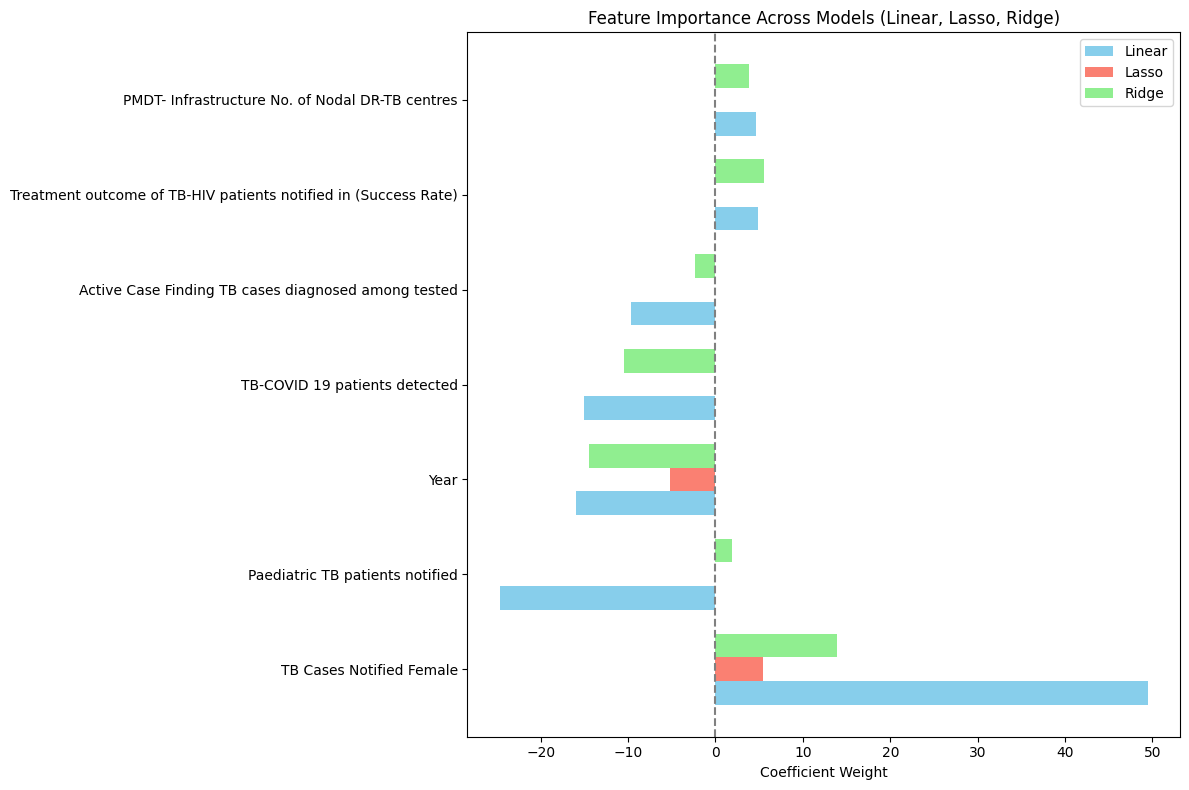

In [956]:
# Встановлюємо розмір фігури
plt.figure(figsize=(12, 8))

# Індекси (назви ознак)
features = coefficients_df['Feature']

# Побудова графіка
x = range(len(features))
plt.barh(x, coefficients_df['Linear Coef'], height=0.25, label='Linear', color='skyblue')
plt.barh([i + 0.25 for i in x], coefficients_df['Lasso Coef'], height=0.25, label='Lasso', color='salmon')
plt.barh([i + 0.5 for i in x], coefficients_df['Ridge Coef'], height=0.25, label='Ridge', color='lightgreen')

# Вісь Y — назви ознак
plt.yticks([i + 0.25 for i in x], features)

# Легенда та стиль
plt.xlabel('Coefficient Weight')
plt.title('Feature Importance Across Models (Linear, Lasso, Ridge)')
plt.axvline(x=0, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()

plt.show()


6. Побудова та порівняння моделей:

6.1 Передбачити щоб код можна було легко доповнювати новими моделями без зміни самої структури коду. Реалізувати такі моделі:
    •	Дерево рішень
    •	Метод найближчих сусідів
    •	Метод опорних векторів (SVM)
    •	Випадковий ліс

6.2 Виконати прогнозування на навчальні і та тестовій вибірці для кожної моделі.

6.3 Оцінити точність моделей за метриками RMSE та R².

In [957]:
# Словник моделей
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVM": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Список для результатів
results = []

# Тренування моделей
for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    pipeline.fit(X_train, y_train)

    # Прогноз
    y_pred = pipeline.predict(X_test)

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Крос-валідація
    cv_r2 = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error'))

    results.append({
        "Model": name,
        "Test RMSE": rmse,
        "Test R²": r2,
        "CV Mean R²": np.mean(cv_r2),
        "CV Mean RMSE": np.mean(cv_rmse)
    })

# Виведення у вигляді таблиці
results_df = pd.DataFrame(results)
print("📊 Порівняння моделей:")
print(results_df)

📊 Порівняння моделей:
           Model  Test RMSE   Test R²  CV Mean R²  CV Mean RMSE
0  Decision Tree  61.331522 -0.021476    0.083337     50.587654
1            KNN  65.588877 -0.168210    0.077377     51.643963
2            SVM  64.668440 -0.135652   -0.078096     55.739788
3  Random Forest  50.686726  0.302332    0.462757     39.436652


7. Порівняльний аналіз:

7.1 Побудувати таблицю з результатами (RMSE, R²) для всіх моделей.
7.2 Візуалізувати порівняння точності моделей у вигляді стовпчастого графіка.
7.3 Зробити висновки про фактори, які найбільше впливають на прогноз в залежності від моделі.


/var/folders/p5/jffj9yld09n0wvq85zzz5y7r0000gn/T/ipykernel_7741/3070105207.py:8: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/borovikdmitry/Documents/Repos/ML_CHI_IT_course/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


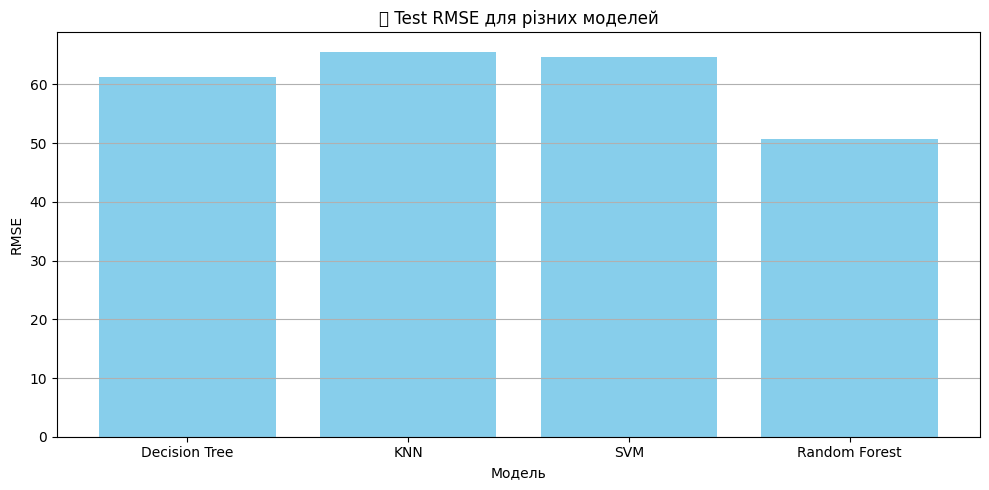

/var/folders/p5/jffj9yld09n0wvq85zzz5y7r0000gn/T/ipykernel_7741/3070105207.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/borovikdmitry/Documents/Repos/ML_CHI_IT_course/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


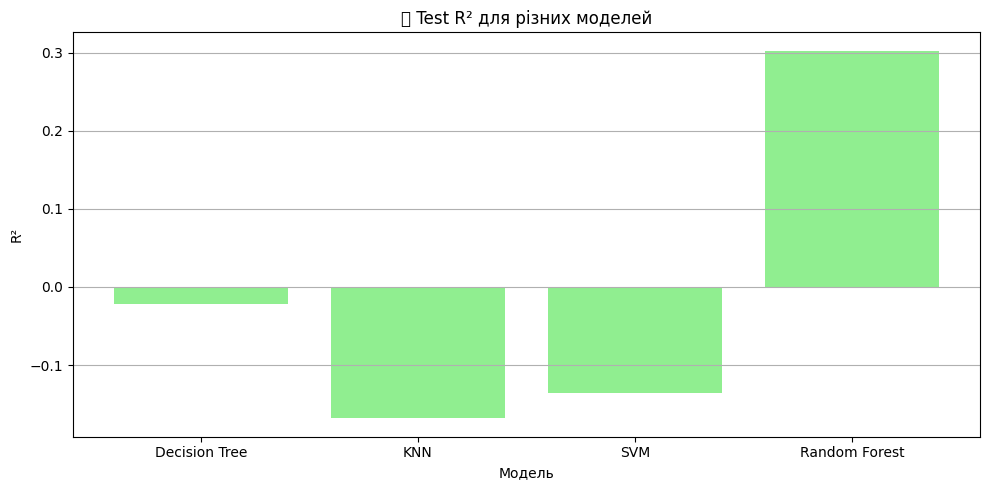

In [958]:
# Візуалізація RMSE
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Test RMSE'], color='skyblue')
plt.title("📉 Test RMSE для різних моделей")
plt.ylabel("RMSE")
plt.xlabel("Модель")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Візуалізація R²
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Test R²'], color='lightgreen')
plt.title("📈 Test R² для різних моделей")
plt.ylabel("R²")
plt.xlabel("Модель")
plt.grid(axis='y')
plt.tight_layout()
plt.show()